# Phase I — Data Preparation and Probabilistic Baselines
**ChestMNIST: pleural effusion present versus absent.**

This notebook prepares the data, implements logistic regression with stochastic gradient ascent (SGA), and evaluates Gaussian Naive Bayes and KNN. It also demonstrates multiclass logistic regression on separate synthetic data, as requested by the assignment.

Run cells in order. Results are generated by execution; no results have been filled in beforehand. ChestMNIST derives from NIH ChestXray14, not CheXpert. Its annotations do not include an explicit uncertain-label category. We do not add label corruption in Phase I.

## 1. Environment
If imports fail, run the installation cell below, then restart the kernel if necessary. `%pip` installs into the current notebook environment. Installation requires an internet connection.

In [20]:
# Uncomment only if dependencies are missing:
# %pip install numpy scikit-learn matplotlib pandas

In [21]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, ConfusionMatrixDisplay)

SEED = 42
LABEL_INDEX = 2  # official ChestMNIST label: effusion
MAX_TRAIN = 10_000
cwd = Path.cwd()
candidates = [cwd / 'chestmnist(1)', cwd.parent / 'chestmnist(1)']
DATA_DIR = next((p for p in candidates if (p / 'train_images.npy').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Set DATA_DIR to the folder containing the six ChestMNIST .npy files.')
PHASE_DIR = cwd if cwd.name == 'phase_1' else cwd / 'phase_1'
OUT = PHASE_DIR / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
print('Dataset:', DATA_DIR.resolve())
print('Outputs:', OUT.resolve())

Dataset: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/chestmnist(1)
Outputs: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_1/outputs


## 2. Load and inspect the data
Each image has shape 28 × 28. Each label row has 14 binary entries because findings can coexist. Column 2 corresponds to effusion. Label 0 means absent; label 1 means present.

Use the supplied splits. Check finite values and label validity before preprocessing. If no values are missing, imputation is unnecessary.

In [22]:
images, labels, targets = {}, {}, {}
rows = []
for split in ('train', 'val', 'test'):
    images[split] = np.load(DATA_DIR / f'{split}_images.npy', mmap_mode='r', allow_pickle=False)
    labels[split] = np.load(DATA_DIR / f'{split}_labels.npy', mmap_mode='r', allow_pickle=False)
    assert images[split].shape[1:] == (28, 28)
    assert labels[split].shape == (len(images[split]), 14)
    assert np.isfinite(images[split]).all(), 'Non-finite image values need investigation.'
    assert np.isin(labels[split], [0, 1]).all(), 'Unexpected label values.'
    targets[split] = labels[split][:, LABEL_INDEX].astype(np.int64)
    counts = np.bincount(targets[split], minlength=2)
    rows.append({'split': split, 'images': len(images[split]),
                 'absent': counts[0], 'present': counts[1],
                 'positive_fraction': counts[1] / counts.sum()})
summary = pd.DataFrame(rows)
summary.to_csv(OUT / 'dataset_summary.csv', index=False)
display(summary)

,split,images,absent,present,positive_fraction
0,train,78468,69207,9261,0.118023
1,val,11219,9927,1292,0.115162
2,test,22433,19679,2754,0.122766


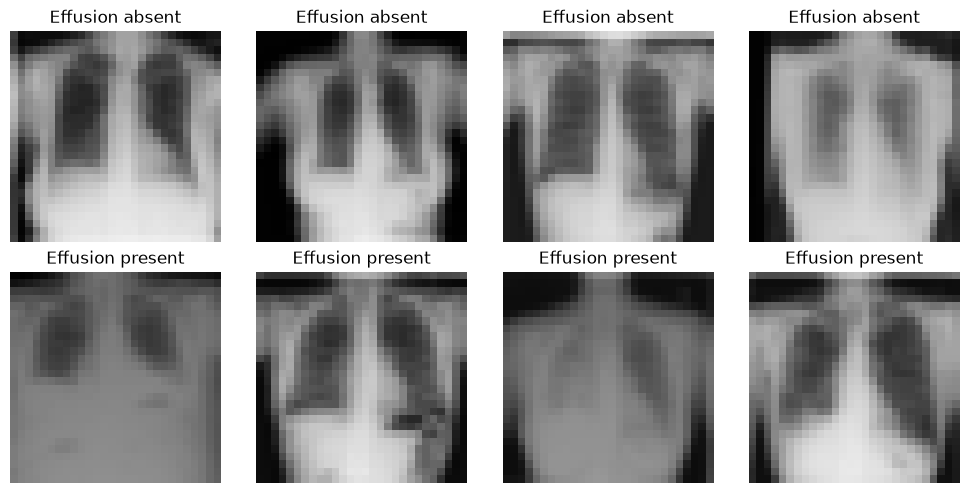

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for cls in (0, 1):
    selected = np.flatnonzero(targets['train'] == cls)[:4]
    for ax, idx in zip(axes[cls], selected):
        ax.imshow(images['train'][idx], cmap='gray', vmin=0, vmax=255)
        ax.set_title('Effusion ' + ('present' if cls else 'absent'))
        ax.axis('off')
plt.tight_layout()
fig.savefig(OUT / 'sample_images.png', dpi=150)
plt.show()

## 3. Prepare features without data leakage
To keep tonight's experiments manageable, use at most 10,000 stratified training images. Save their indices for reuse in later phases. Flatten images into 784 features and map pixel values to [0, 1].

The model pipelines below fit scaling and PCA on training data only. PCA retains 50 dimensions to reduce KNN computation. This choice loses some image information and should be reported in the article. All three baseline families use the same preprocessing.

In [24]:
all_indices = np.arange(len(images['train']))
if len(all_indices) > MAX_TRAIN:
    train_indices, _ = train_test_split(all_indices, train_size=MAX_TRAIN,
                                       stratify=targets['train'], random_state=SEED)
else:
    train_indices = all_indices
np.save(OUT / 'train_indices.npy', train_indices)

def flatten(arr):
    return np.asarray(arr, dtype=np.float32).reshape(len(arr), -1) / 255.0

X_train = flatten(images['train'][train_indices])
y_train = targets['train'][train_indices]
X_val, y_val = flatten(images['val']), targets['val']
# Test features are prepared only in the final evaluation cell.
print('Training features:', X_train.shape)
print('Training class counts:', np.bincount(y_train, minlength=2))
config = {'seed': SEED, 'target': 'effusion', 'label_index': LABEL_INDEX,
          'max_train': MAX_TRAIN, 'actual_train': len(y_train),
          'preprocessing': 'pixels / 255, StandardScaler, PCA(50)',
          'dataset': 'ChestMNIST derived from NIH ChestXray14'}
(OUT / 'phase1_config.json').write_text(json.dumps(config, indent=2))

Training features: (10000, 784)
Training class counts: [8820 1180]


223

## 4. Logistic regression with stochastic gradient ascent
For binary classification, sigmoid converts a weighted feature score into a probability. We maximize log-likelihood with an L2 penalty. A one-example ascent update is proportional to `(y − probability) × features`, minus the regularization gradient.

The implementation also supports multiclass softmax. Samples are shuffled each epoch, and the learning rate decreases with epochs. Loss shown during training is negative log-likelihood plus the penalty. Lower loss is better.

In [25]:
class LogisticSGA(ClassifierMixin, BaseEstimator):
    def __init__(self, learning_rate=0.01, epochs=20, l2=0.001, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.l2 = l2
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        self.classes_, encoded = np.unique(y, return_inverse=True)
        if len(self.classes_) < 2:
            raise ValueError('At least two classes are required.')
        binary = len(self.classes_) == 2
        width = 1 if binary else len(self.classes_)
        self.weights_ = np.zeros((X.shape[1], width))
        self.bias_ = np.zeros(width)
        self.loss_history_ = []
        rng = np.random.default_rng(self.random_state)
        for epoch in range(self.epochs):
            rate = self.learning_rate / np.sqrt(epoch + 1)
            for i in rng.permutation(len(X)):
                score = X[i] @ self.weights_ + self.bias_
                if binary:
                    prob = 1 / (1 + np.exp(-np.clip(score, -500, 500)))
                    error = np.array([encoded[i]]) - prob
                else:
                    exp_score = np.exp(score - score.max())
                    prob = exp_score / exp_score.sum()
                    error = np.eye(width)[encoded[i]] - prob
                self.weights_ += rate * (np.outer(X[i], error) - self.l2 * self.weights_)
                self.bias_ += rate * error
            probabilities = self.predict_proba(X)
            loss = -np.log(np.clip(probabilities[np.arange(len(X)), encoded], 1e-12, 1)).mean()
            self.loss_history_.append(loss + self.l2 * np.square(self.weights_).sum() / 2)
        return self

    def predict_proba(self, X):
        score = np.asarray(X) @ self.weights_ + self.bias_
        if len(self.classes_) == 2:
            p = 1 / (1 + np.exp(-np.clip(score[:, 0], -500, 500)))
            return np.column_stack([1 - p, p])
        exp_score = np.exp(score - score.max(axis=1, keepdims=True))
        return exp_score / exp_score.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


def make_pipeline(model):
    return Pipeline([('scale', StandardScaler()),
                     ('pca', PCA(n_components=50, svd_solver='randomized', random_state=SEED)),
                     ('model', model)])

## 5. Train and select models using validation data
Gaussian Naive Bayes assumes conditional feature independence and Gaussian feature distributions. PCA removes linear correlation in training data, but does not guarantee independence.

KNN votes among nearby examples. Test K = 3, 5 and 11. High dimensionality makes distance less informative, which motivates the shared PCA preprocessing.

Use positive-class AP for selection. Keep the probability threshold at 0.5 for precision, recall and F1. AP is not trapezoidal PR-AUC.

In [16]:
def metrics(y, probability):
    prediction = (probability >= 0.5).astype(int)
    return {'accuracy': accuracy_score(y, prediction),
            'precision': precision_score(y, prediction, zero_division=0),
            'recall': recall_score(y, prediction, zero_division=0),
            'f1': f1_score(y, prediction, zero_division=0),
            'roc_auc': roc_auc_score(y, probability),
            'average_precision': average_precision_score(y, probability)}

candidates = {
    'LogReg_SGA_lr0.01': LogisticSGA(learning_rate=0.01, random_state=SEED),
    'LogReg_SGA_lr0.001': LogisticSGA(learning_rate=0.001, random_state=SEED),
    'GaussianNB': GaussianNB(),
    **{f'KNN_k{k}': KNeighborsClassifier(n_neighbors=k, n_jobs=-1) for k in (3, 5, 11)}
}
fitted, durations, validation_rows = {}, {}, []
for name, estimator in candidates.items():
    model = make_pipeline(estimator)
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    probability = model.predict_proba(X_val)[:, 1]
    validation_rows.append({'model': name, 'fit_seconds': fit_seconds,
                            **metrics(y_val, probability)})
    fitted[name], durations[name] = model, fit_seconds
    print(name, 'completed')
validation_results = pd.DataFrame(validation_rows).sort_values('average_precision', ascending=False)
validation_results.to_csv(OUT / 'validation_metrics.csv', index=False)
display(validation_results)

families = {'Logistic regression SGA': ['LogReg_SGA_lr0.01', 'LogReg_SGA_lr0.001'],
            'Gaussian Naive Bayes': ['GaussianNB'],
            'KNN': [f'KNN_k{k}' for k in (3, 5, 11)]}
selected = {}
for family, names in families.items():
    best = validation_results[validation_results.model.isin(names)].iloc[0]['model']
    selected[family] = best
print('Selected configurations:', selected)
(OUT / 'selected_models.json').write_text(json.dumps(selected, indent=2))

LogReg_SGA_lr0.01 completed
LogReg_SGA_lr0.001 completed
GaussianNB completed
KNN_k3 completed
KNN_k5 completed
KNN_k11 completed


,model,fit_seconds,accuracy,precision,recall,f1,roc_auc,average_precision
2,GaussianNB,1.602655,0.869329,0.311688,0.111455,0.164196,0.730899,0.244963
1,LogReg_SGA_lr0.001,6.855778,0.881540,0.271605,0.017028,0.032047,0.723998,0.236945
5,KNN_k11,1.926664,0.882788,0.390476,0.031734,0.058697,0.689071,0.213658
0,LogReg_SGA_lr0.01,6.881606,0.863089,0.274908,0.115325,0.162486,0.641316,0.187210
4,KNN_k5,1.911093,0.872716,0.300000,0.078947,0.125000,0.641127,0.178119
3,KNN_k3,1.865809,0.862287,0.274510,0.119195,0.166217,0.605745,0.160999


Selected configurations: {'Logistic regression SGA': 'LogReg_SGA_lr0.001', 'Gaussian Naive Bayes': 'GaussianNB', 'KNN': 'KNN_k11'}


113

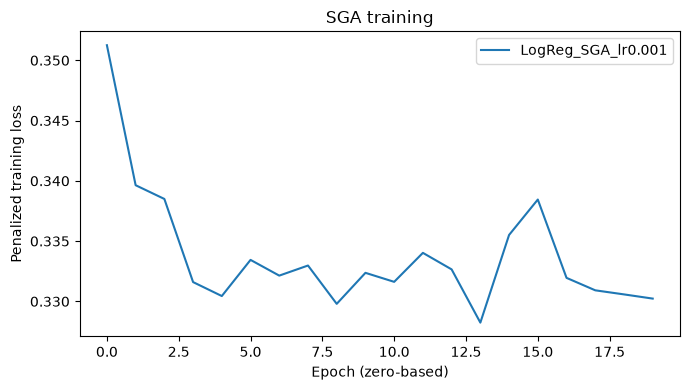

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
for family, name in selected.items():
    if family == 'Logistic regression SGA':
        ax.plot(fitted[name].named_steps['model'].loss_history_, label=name)
ax.set(xlabel='Epoch (zero-based)', ylabel='Penalized training loss', title='SGA training')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'sga_training_loss.png', dpi=150)
plt.show()

## 6. Final test evaluation
Run this section after model configurations are fixed. Do not use its results to adjust parameters. Evaluation compares predictions with dataset annotations; it does not establish clinical suitability.

Random-ranking precision is approximately the positive-class prevalence, shown on the precision–recall plot.

,family,model,fit_seconds,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic regression SGA,LogReg_SGA_lr0.001,6.855778,0.875362,0.340909,0.016340,0.031185,0.715165,0.250852
1,Gaussian Naive Bayes,GaussianNB,1.602655,0.861008,0.297778,0.097313,0.146689,0.715859,0.240193
2,KNN,KNN_k11,1.926664,0.874114,0.328431,0.024328,0.045301,0.673514,0.203074


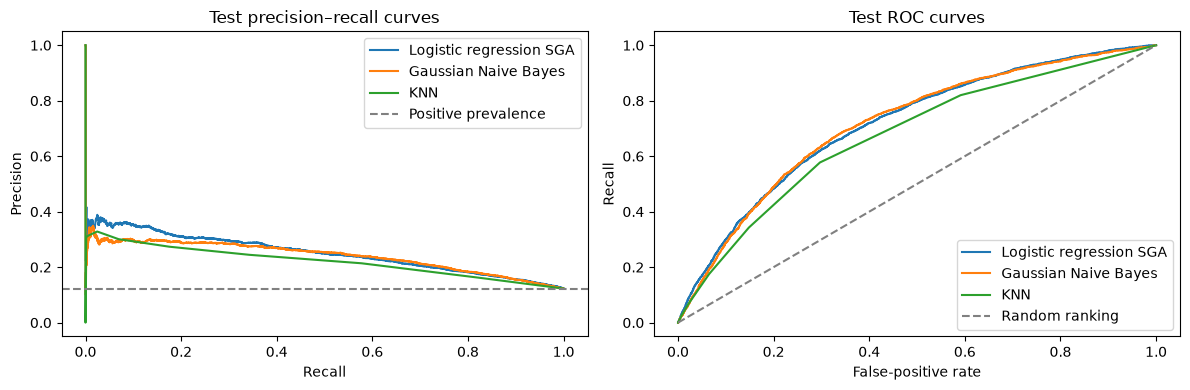

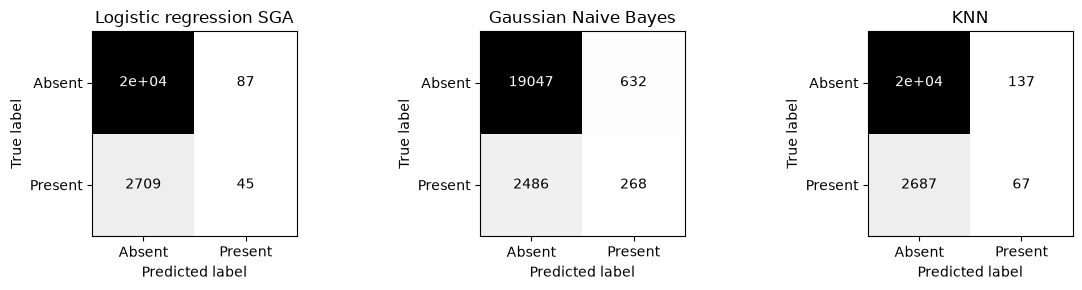

In [18]:
X_test, y_test = flatten(images['test']), targets['test']
test_rows, test_probabilities = [], {}
for family, name in selected.items():
    prob = fitted[name].predict_proba(X_test)[:, 1]
    test_probabilities[family] = prob
    test_rows.append({'family': family, 'model': name,
                      'fit_seconds': durations[name], **metrics(y_test, prob)})
test_results = pd.DataFrame(test_rows)
test_results.to_csv(OUT / 'test_metrics.csv', index=False)
display(test_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for family, prob in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(recall, precision, label=family)
    axes[1].plot(fpr, tpr, label=family)
axes[0].axhline(y_test.mean(), linestyle='--', color='gray', label='Positive prevalence')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random ranking')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Test precision–recall curves')
axes[1].set(xlabel='False-positive rate', ylabel='Recall', title='Test ROC curves')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'test_curves.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (family, prob) in zip(axes, test_probabilities.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, (prob >= 0.5).astype(int),
        display_labels=['Absent', 'Present'], ax=ax, colorbar=False, cmap='Greys')
    ax.set_title(family)
fig.tight_layout()
fig.savefig(OUT / 'test_confusion_matrices.png', dpi=150)
plt.show()

## 7. Auxiliary multiclass logistic regression
ChestMNIST is multilabel, not mutually exclusive multiclass. This separate synthetic experiment demonstrates softmax SGA on three exclusive classes. Do not mix its metrics with the medical benchmark.

In [19]:
from sklearn.datasets import make_classification
X_multi, y_multi = make_classification(n_samples=1200, n_features=10,
    n_informative=6, n_redundant=0, n_classes=3, n_clusters_per_class=1,
    random_state=SEED)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.25, stratify=y_multi, random_state=SEED)
multi_model = Pipeline([('scale', StandardScaler()),
                        ('model', LogisticSGA(epochs=30, random_state=SEED))])
multi_model.fit(Xm_train, ym_train)
pred_multi = multi_model.predict(Xm_test)
multiclass_result = {'dataset': 'synthetic_three_class',
                    'accuracy': accuracy_score(ym_test, pred_multi),
                    'macro_f1': f1_score(ym_test, pred_multi, average='macro')}
print(multiclass_result)
(OUT / 'synthetic_multiclass_metrics.json').write_text(json.dumps(multiclass_result, indent=2))

{'dataset': 'synthetic_three_class', 'accuracy': 0.8933333333333333, 'macro_f1': 0.8923678980474112}


108

## 8. Interpretation and handoff
After execution, describe which baseline has the highest validation AP, compare test precision and recall, discuss class imbalance, and explain the limits of 28 × 28 images and the reduced training subset. Do not claim a winner before observing the results.

Give the Phase III teammate the subset indices, seed, preprocessing configuration, model implementations and CSV tables. Phase III introduces label noise and MLflow tracking. Phases II and IV cover additional models and the research comparison.

The notebook creates outputs only when run. Keep original dataset arrays unchanged.

Gaussian Naive Bayes obtained the highest validation average precision (AP = 0.245). Within the other model families, validation selected logistic regression with learning rate 0.001 and KNN with K = 11.
On the test set, logistic regression obtained the highest AP (0.251), while Gaussian Naive Bayes achieved the highest recall (9.73%) and F1-score (14.67%) at threshold 0.5. All models missed most effusion-positive cases. Their relatively high accuracy therefore does not demonstrate effective positive-case detection.
Logistic regression’s training loss decreased rapidly before fluctuating around a plateau. This improvement in the training objective did not translate into high recall.
The experiments used 10,000 training images, 28 × 28 resolution, and PCA with 50 components. These choices reduced computation but may discard useful image information. The results concern dataset annotations and do not establish clinical suitability.
The separate synthetic three-class experiment achieved 89.33% accuracy and 89.24% macro-F1. It demonstrates multiclass functionality and is reported separately from the medical results.